https://github.com/abhisheksuran/Reinforcement_Learning/blob/master/SoftAC.ipynb

In [1]:
from google.colab import drive
drive.mount('./gdrive')

Mounted at ./gdrive


In [2]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib') # add library path
from variable_print import p,ps,pst

In [3]:
%%time
%%capture
!pip install swig
!pip install gymnasium[box2d]

CPU times: user 3.43 s, sys: 1.28 s, total: 4.72 s
Wall time: 55.9 s


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions.normal import Normal
import time

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore")

## Env

## Replay Buffer

In [7]:
class ReplayBuffer:
    def __init__(self, obs_dim, act_dim, size):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.obs2_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros((size, act_dim), dtype=np.float32)
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.float32)
        self.ptr, self.size, self.max_size = 0, 0, size

    def store(self, obs, act, rew, next_obs, done):
        self.obs_buf[self.ptr] = obs
        self.obs2_buf[self.ptr] = next_obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.done_buf[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self, batch_size=32):
        # 버퍼에 저장된 만큼만 샘플링
        idxs = np.random.randint(0, self.size, size=batch_size)
        batch = dict(obs=self.obs_buf[idxs],
                     obs2=self.obs2_buf[idxs],
                     act=self.act_buf[idxs],
                     rew=self.rew_buf[idxs],
                     done=self.done_buf[idxs])
        # NumPy 배열을 PyTorch 텐서로 변환
        return {k: torch.as_tensor(v, dtype=torch.float32) for k, v in batch.items()}

## Actor Critic Network

In [8]:
LOG_STD_MAX = 2
LOG_STD_MIN = -20

class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes, activation, act_limit):
        super().__init__()
        self.act_limit = act_limit
        layers = []
        layers.append(nn.Linear(obs_dim, hidden_sizes[0]))
        layers.append(activation())
        for i in range(len(hidden_sizes)-1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
            layers.append(activation())

        self.net = nn.Sequential(*layers)
        # 평균(mu)과 표준편차(log_std)를 위한 별도의 출력층
        self.mu_layer = nn.Linear(hidden_sizes[-1], act_dim)
        self.log_std_layer = nn.Linear(hidden_sizes[-1], act_dim)

    def forward(self, obs, deterministic=False, with_logprob=True):
        net_out = self.net(obs)
        mu = self.mu_layer(net_out)
        log_std = self.log_std_layer(net_out)
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)
        std = torch.exp(log_std)
        pi_distribution = Normal(mu, std)

        if deterministic:
            pi_action = mu
        else:
            pi_action = pi_distribution.rsample() # Reparameterization Trick
        logp_pi = None
        if with_logprob:
            # Tanh 변환에 대한 로그 확률 보정
            logp_pi = pi_distribution.log_prob(pi_action).sum(axis=-1)
            logp_pi -= (2 * (np.log(2) - pi_action - F.softplus(-2 * pi_action))).sum(axis=1)

        # Tanh를 통해 액션 범위를 [-1, 1]로 조정
        pi_action = torch.tanh(pi_action)
        # 액션 범위에 맞게 스케일 조정
        pi_action = self.act_limit * pi_action
        return pi_action, logp_pi


class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes, activation):
        super().__init__()
        # Q1 네트워크
        self.q1 = self._build_net(obs_dim, act_dim, hidden_sizes, activation)
        # Q2 네트워크
        self.q2 = self._build_net(obs_dim, act_dim, hidden_sizes, activation)

    def _build_net(self, obs_dim, act_dim, hidden_sizes, activation):
        layers = []
        layers.append(nn.Linear(obs_dim + act_dim, hidden_sizes[0]))
        layers.append(activation())
        for i in range(len(hidden_sizes)-1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
            layers.append(activation())
        layers.append(nn.Linear(hidden_sizes[-1], 1))

        return nn.Sequential(*layers)

    def forward(self, obs, act):
        # 상태와 액션을 합쳐서 입력으로 사용
        q1_input = torch.cat([obs, act], dim=-1)
        q2_input = torch.cat([obs, act], dim=-1)
        q1 = self.q1(q1_input)
        q2 = self.q2(q2_input)
        return torch.squeeze(q1, -1), torch.squeeze(q2, -1)

In [11]:
class SACAgent:
    def __init__(self, obs_dim, act_dim, act_limit, hidden_sizes=(256, 256), activation=nn.ReLU,
                 gamma=0.99, polyak=0.995, lr=1e-3, alpha=0.2):
        self.act_limit = act_limit
        self.gamma = gamma
        self.polyak = polyak
        self.alpha = alpha

        # Actor-Critic 네트워크
        self.actor = Actor(obs_dim, act_dim, hidden_sizes, activation, act_limit)
        self.critic = Critic(obs_dim, act_dim, hidden_sizes, activation)
        self.critic_target = Critic(obs_dim, act_dim, hidden_sizes, activation)

        # 타겟 네트워크 초기화
        self.critic_target.load_state_dict(self.critic.state_dict())

        # 옵티마이저
        self.q_optimizer = optim.Adam(self.critic.parameters(), lr=lr)
        self.policy_optimizer = optim.Adam(self.actor.parameters(), lr=lr)

    def get_action(self, obs, deterministic=False):
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
        action, _ = self.actor(obs_tensor, deterministic, False)
        return action.detach().numpy()

    def update(self, data):
        obs, act, rew, obs2, done = data['obs'], data['act'], data['rew'], data['obs2'], data['done']

        # 1. Critic (Q-네트워크) 손실 계산 및 업데이트
        q1, q2 = self.critic(obs, act)

        with torch.no_grad():
            a2, logp_a2 = self.actor(obs2)
            q1_target, q2_target = self.critic_target(obs2, a2)
            q_target = torch.min(q1_target, q2_target)
            backup = rew + self.gamma * (1 - done) * (q_target - self.alpha * logp_a2)

        loss_q1 = F.mse_loss(q1, backup)
        loss_q2 = F.mse_loss(q2, backup)
        loss_q = loss_q1 + loss_q2

        self.q_optimizer.zero_grad()
        loss_q.backward()
        self.q_optimizer.step()

        # 2. Actor (정책 네트워크) 손실 계산 및 업데이트
        # Q 네트워크의 그래디언트 계산을 비활성화
        for p in self.critic.parameters():
            p.requires_grad = False

        pi, logp_pi = self.actor(obs)
        q1_pi, q2_pi = self.critic(obs, pi)
        q_pi = torch.min(q1_pi, q2_pi)
        loss_pi = (self.alpha * logp_pi - q_pi).mean()

        self.policy_optimizer.zero_grad()
        loss_pi.backward()
        self.policy_optimizer.step()

        # Q 네트워크의 그래디언트 계산을 다시 활성화
        for p in self.critic.parameters():
            p.requires_grad = True

        # 3. 타겟 네트워크 업데이트 (Polyak Averaging)
        with torch.no_grad():
            for p, p_targ in zip(self.critic.parameters(), self.critic_target.parameters()):
                p_targ.data.mul_(self.polyak)
                p_targ.data.add_((1 - self.polyak) * p.data)

## Train

In [24]:
# --- 환경 및 에이전트 초기화 ---
env = gym.make("Pendulum-v1", render_mode="rgb_array") # Added render_mode
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]
act_limit = env.action_space.high[0]

agent = SACAgent(obs_dim, act_dim, act_limit)
replay_buffer = ReplayBuffer(obs_dim=obs_dim, act_dim=act_dim, size=1000000)

# --- 하이퍼파라미터 ---
total_steps = 5000 #100000
update_after = 1000
update_every = 50
batch_size = 128

# --- 메인 학습 루프 ---
obs, _ = env.reset()
ep_ret, ep_len = 0, 0

for t in range(total_steps):
    if t > 1000: # 초기에는 랜덤 액션
        action = agent.get_action(obs)
    else:
        action = env.action_space.sample()

    # [수정] env.step 반환값 5개로 변경
    obs2, rew, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    ep_ret += rew
    ep_len += 1

    # done이 True일 때만 1, 아니면 0 저장
    replay_buffer.store(obs, action, rew, obs2, done)
    obs = obs2

    # 에피소드 종료 처리
    if done or (ep_len == 1000):
        print(f"Step: {t}, Episode Return: {ep_ret:.2f}, Episode Length: {ep_len}")
        obs, _ = env.reset()
        ep_ret, ep_len = 0, 0

    # SAC 에이전트 업데이트
    if t >= update_after and t % update_every == 0:
        for _ in range(update_every):
            batch = replay_buffer.sample_batch(batch_size)
            agent.update(data=batch)

Step: 199, Episode Return: -1274.18, Episode Length: 200
Step: 399, Episode Return: -1603.10, Episode Length: 200
Step: 599, Episode Return: -1343.04, Episode Length: 200
Step: 799, Episode Return: -979.81, Episode Length: 200
Step: 999, Episode Return: -746.29, Episode Length: 200
Step: 1199, Episode Return: -1287.21, Episode Length: 200
Step: 1399, Episode Return: -1727.07, Episode Length: 200
Step: 1599, Episode Return: -1648.65, Episode Length: 200
Step: 1799, Episode Return: -1724.78, Episode Length: 200
Step: 1999, Episode Return: -1674.89, Episode Length: 200
Step: 2199, Episode Return: -1666.70, Episode Length: 200
Step: 2399, Episode Return: -1620.17, Episode Length: 200
Step: 2599, Episode Return: -1291.83, Episode Length: 200
Step: 2799, Episode Return: -1157.68, Episode Length: 200
Step: 2999, Episode Return: -538.82, Episode Length: 200
Step: 3199, Episode Return: -901.48, Episode Length: 200
Step: 3399, Episode Return: -1124.89, Episode Length: 200
Step: 3599, Episode Ret

## Test

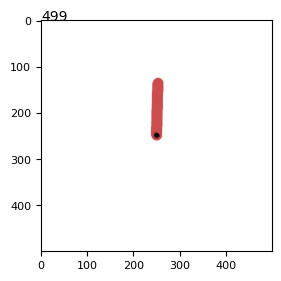

-121.5934004950547


In [25]:
from IPython.display import clear_output
import numpy as np
env = gym.make("Pendulum-v1", render_mode="rgb_array") # Added render_mode

state,_ = env.reset()
action_l = []
rewards = 0
for i in range(500): # while True:
    plt.figure(figsize=(5,3))
    img_data = env.render()
    plt.imshow(np.array(img_data, dtype=np.uint8))
    plt.text(0,0,str(i),fontsize=10)
    action = agent.get_action(state)
    state, reward, done , info, _ = env.step(action)
    clear_output(wait=True)
    rewards += reward
    if done: break;
    else: plt.show() # show the plot only if the episode is not done
plt.show()
print(rewards)
env.close()